## Configuration and Dataset Download

In [ ]:
from google.colab import files
files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!pip install kagglehub
import kagglehub

Saving kaggle (1).json to kaggle (1) (1).json


{'kaggle (1) (1).json': b'{"username":"haniehmz","key":"782264ab995d5289cb2fb7eb66c53d9e"}'}

In [ ]:
path = kagglehub.dataset_download("sanjeetsinghnaik/google-recaptcha")
print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/google-recaptcha


## YOLO Object Detection on Images

Using cache found in /root/.cache/torch/hub/ultralytics_yolov5_master
YOLOv5 🚀 2025-5-28 Python-3.11.12 torch-2.6.0+cu124 CPU

Fusing layers... 
YOLOv5s summary: 213 layers, 7225885 parameters, 0 gradients, 16.4 GFLOPs
Adding AutoShape... 


 Raw Image: Hydrant (73).png


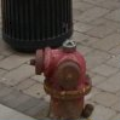

/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:906: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
image 1/1: 120x120 3 fire hydrants
Speed: 1.4ms pre-process, 73.0ms inference, 1.0ms NMS per image at shape (1, 3, 224, 224)


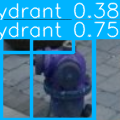

,xmin,ymin,xmax,ymax,confidence,class,name
0,31.761234,38.950363,93.472923,119.004753,0.746770,10,fire hydrant
1,1.382810,0.268769,73.412689,52.730682,0.375565,10,fire hydrant
2,1.190410,0.588255,94.652695,119.352364,0.338244,10,fire hydrant


 Raw Image: Tlight (811).png


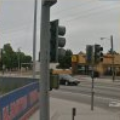

/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:906: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
image 1/1: 120x120 1 car, 4 traffic lights
Speed: 1.2ms pre-process, 83.8ms inference, 1.0ms NMS per image at shape (1, 3, 224, 224)


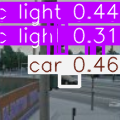

,xmin,ymin,xmax,ymax,confidence,class,name
0,59.155521,73.744904,79.653557,86.236160,0.458780,2,car
1,48.743828,20.670170,59.497276,60.837780,0.444013,9,traffic light
2,55.808220,22.896412,66.282021,54.877106,0.398425,9,traffic light
3,94.697098,44.318497,103.394310,61.163700,0.305400,9,traffic light
4,86.382912,44.588612,91.986923,60.729198,0.297870,9,traffic light


 Raw Image: Car (742).png


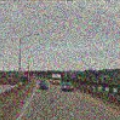

/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:906: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
image 1/1: 120x120 (no detections)
Speed: 1.1ms pre-process, 81.2ms inference, 0.7ms NMS per image at shape (1, 3, 224, 224)


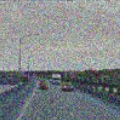

,xmin,ymin,xmax,ymax,confidence,class,name


 Raw Image: Bus (43).png


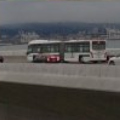

/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:906: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
image 1/1: 120x120 2 buss
Speed: 1.2ms pre-process, 77.9ms inference, 1.1ms NMS per image at shape (1, 3, 224, 224)


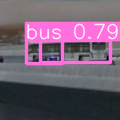

,xmin,ymin,xmax,ymax,confidence,class,name
0,26.343718,40.055599,62.629704,63.125835,0.789778,5,bus
1,40.368385,40.443577,110.032684,62.649143,0.475066,5,bus


 Raw Image: Bicycle (526).png


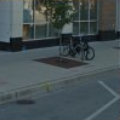

/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:906: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
image 1/1: 120x120 1 bicycle
Speed: 1.2ms pre-process, 85.2ms inference, 1.0ms NMS per image at shape (1, 3, 224, 224)


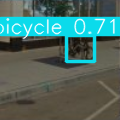

,xmin,ymin,xmax,ymax,confidence,class,name
0,66.199997,35.293949,94.729973,61.591812,0.709327,1,bicycle


In [ ]:
import cv2
import os
import torch
import random
from IPython.display import display
from google.colab.patches import cv2_imshow

image_paths = []
for root, dirs, files in os.walk(path):
    for file in files:
        if file.lower().endswith(('.jpg', '.jpeg', '.png')):
            image_paths.append(os.path.join(root, file))

sample_image_path = random.sample(image_paths,5)
yolo_model = torch.hub.load("ultralytics/yolov5", "yolov5s")

def detect_objects(image_path, details=False):
  image = cv2.imread(image_path)
  print(f" Raw Image: {os.path.basename(image_path)}")
  cv2_imshow(image)
  results = yolo_model(image, size=200)
  results.print()
  results.show()
  if details:
    display(results.pandas().xyxy[0])
  return results.pandas().xyxy[0]['name'].tolist()

for p in sample_image_path:
  predicted_labels = detect_objects(p, details=True)



## YOLO Object Detection with Webcam

In [ ]:
import cv2
import torch

model = torch.hub.load('ultralytics/yolov5', 'yolov5s')
cap = cv2.VideoCapture(0)

while True:
    ret, frame = cap.read()
    if not ret:
        break

    results = model(frame)
    results.render()

    cv2.imshow('YOLO Live Detection', results.ims[0])

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()